# 02 — Subtopic Classification via BERTopic Clustering

Discovers 10–20 AI subtopics **data-driven** (no predefined keywords) using:
1. Sentence-BERT embeddings (`all-mpnet-base-v2` — 768-dim, 12-layer)
2. UMAP dimensionality reduction → 10D
3. HDBSCAN density clustering → auto topic count
4. BERTopic c-TF-IDF for human-readable topic labels
5. **Soft / multi-label assignment** — every article is assigned to its top-k
   probable topics (k ≥ 1) via approximate cosine similarity to topic centroids,
   so one article can carry multiple subtopic labels.

Input : `data/raw_articles.csv`  
Output: `data/classified_articles.csv`  
Side  : `data/topic_info.csv`, `data/embeddings.npy` (cached)

> **Model note:** `all-mpnet-base-v2` (768-dim) replaces the previous `all-MiniLM-L6-v2`
> (384-dim). The higher dimensionality gives UMAP and HDBSCAN far more signal to separate
> 10–20 distinct AI subtopics. One-time encode cost: ~3–4 h on CPU, ~30 min on GPU.
> After that it reads from the cache and is instant.

In [1]:
# pip install sentence-transformers bertopic umap-learn hdbscan scikit-learn
import pandas as pd
import numpy as np
import warnings, os
warnings.filterwarnings('ignore')

df = pd.read_csv('data/raw_articles.csv', parse_dates=['date'])
print(f'Loaded {len(df):,} articles')
df.head(2)

Loaded 4,490 articles


,id,date,section,headline,body,wordcount,url
0,technology/2025/nov/14/people-in-the-uk-have-y...,2025-11-14,Technology,People in the UK: have you received good or ba...,Tech companies are pumping billions into the g...,151,https://www.theguardian.com/technology/2025/no...
1,technology/2026/jan/28/artificial-intelligence...,2026-01-28,Technology,"Artificial intelligence will cost jobs, admits...",Increasing deployment of artificial intelligen...,470,https://www.theguardian.com/technology/2026/ja...


## Step 1 — Prepare Text
Use headline + first 512 chars of body. Keeps context rich enough for embeddings
without slowing encode time.

In [2]:
df['text_input'] = (
    df['headline'].fillna('') + '. ' +
    df['body'].fillna('').str[:512]
)
df = df[df['text_input'].str.len() > 30].reset_index(drop=True)
print(f'Articles after quality filter: {len(df):,}')

Articles after quality filter: 4,490


## Step 2 — Embed with Sentence-Transformers

**Model: `all-mpnet-base-v2`** (768-dim, 12 Transformer layers, ~420 MB)  
- ~3–4 h on CPU for 23k articles (one-time); ~30 min on GPU
- 2× the embedding dimensions of MiniLM-L6 → much richer semantic space for UMAP/HDBSCAN
- Embeddings cached to `data/embeddings.npy` — subsequent runs load instantly

> **Important:** The cache is model-specific. If you switch models, delete
> `data/embeddings.npy` first, otherwise the dim-assertion below will catch it.

In [3]:
from sentence_transformers import SentenceTransformer

EMBED_MODEL = 'all-mpnet-base-v2'   # 768-dim, 12-layer
EMBED_CACHE = 'data/embeddings.npy'

if os.path.exists(EMBED_CACHE):
    embeddings = np.load(EMBED_CACHE)
    print(f'Loaded cached embeddings: {embeddings.shape}')
    assert len(embeddings) == len(df), (
        f'Cache size mismatch ({len(embeddings)} vs {len(df)} articles). '
        'Delete data/embeddings.npy and re-run.'
    )
    assert embeddings.shape[1] == 768, (
        f'Expected 768-dim embeddings for {EMBED_MODEL}, got {embeddings.shape[1]}. '
    )
else:
    print(f'Encoding {len(df):,} articles with {EMBED_MODEL}...')
    print('Expected time: ~1–2 h on CPU, ~2 min on APPLE M4. Grab a coffee.')
    model = SentenceTransformer(EMBED_MODEL)
    embeddings = model.encode(
        df['text_input'].tolist(),
        batch_size=32,
        show_progress_bar=True,
        normalize_embeddings=True,
    )
    np.save(EMBED_CACHE, embeddings)
    print(f'Embeddings saved → {EMBED_CACHE}  shape: {embeddings.shape}')

Encoding 4,490 articles with all-mpnet-base-v2...
Expected time: ~1–2 h on CPU, ~30 min on GPU. Grab a coffee.


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/141 [00:00<?, ?it/s]

Embeddings saved → data/embeddings.npy  shape: (4490, 768)


## Step 3 — BERTopic: Discover 10–20 Topics

Key hyperparameters (tuned for 768-dim mpnet embeddings + ~23k docs):

| Param | Value | Rationale |
|---|---|---|
| `MIN_CLUSTER_SIZE` | ~48 (0.2% of corpus) | Was ~120 (0.5%) → was too coarse, merging distinct subtopics |
| `n_components` (UMAP) | 10 | Was 5 → preserves more structure from 768-dim space before clustering |
| `min_samples` (HDBSCAN) | 5 | Was 10 → allows detection of smaller, tighter topic clusters |
| `min_df` (vectorizer) | 0.3% | Was 0.5% → includes slightly rarer but topically meaningful terms |
| `NR_TOPICS` | `'auto'` | BERTopic merges near-duplicate topics automatically |

**If you get < 10 topics:** lower `MIN_CLUSTER_SIZE` (try `len(df) // 700`)  
**If you get > 20 topics:** set `NR_TOPICS = 15` to force merging  
**Outlier topic -1** is reassigned in Step 5 via centroid similarity — don't worry about it here

In [25]:
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

# ── Tunable knobs ────────────────────────────────────────────
MIN_CLUSTER_SIZE = 120   # ~4 for 4k docs (0.2% of corpus)
NR_TOPICS        = 'auto'  # BERTopic auto-merges near-duplicate topics
#   → If result < 10 topics: lower to max(30, len(df) // 700)
#   → If result > 20 topics: set NR_TOPICS = 15 to force merging
# ─────────────────────────────────────────────────────────────

umap_model = UMAP(
    n_components=10,     # 5→10: preserves more structure from 768-dim embeddings
    n_neighbors=15,      # local connectivity — good balance for 23k docs
    min_dist=0.0,        # keep tight for density-based downstream clustering
    metric='cosine',
    random_state=42,
)

hdbscan_model = HDBSCAN(
    min_cluster_size=MIN_CLUSTER_SIZE,
    min_samples=5,       # 10→5: detects smaller, tighter topic clusters
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True,   # required for soft-clustering in Step 5
)

vectorizer = CountVectorizer(
    stop_words='english',
    ngram_range=(1, 2),
    min_df=0.003,        # 0.5%→0.3%: slightly rarer but topically meaningful terms
    max_df=0.90,
)

topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer,
    nr_topics=NR_TOPICS,
    top_n_words=12,
    verbose=True,
)

topics, probs = topic_model.fit_transform(
    df['text_input'].tolist(),
    embeddings=embeddings,   # reuse precomputed 768-dim embeddings
)

df['topic_id'] = topics

topic_info = topic_model.get_topic_info()
n_real    = (topic_info['Topic'] >= 0).sum()
n_outlier = (df['topic_id'] == -1).sum()
print(f'\nTopics found: {n_real}  |  Outlier articles (topic -1): {n_outlier:,}')
print(f'(Target: 10–20 topics. Adjust MIN_CLUSTER_SIZE if outside range.)\n')
topic_info

2026-02-19 19:22:01,141 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-02-19 19:22:04,813 - BERTopic - Dimensionality - Completed ✓
2026-02-19 19:22:04,813 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-02-19 19:22:04,863 - BERTopic - Cluster - Completed ✓
2026-02-19 19:22:04,863 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-02-19 19:22:05,348 - BERTopic - Representation - Completed ✓
2026-02-19 19:22:05,349 - BERTopic - Topic reduction - Reducing number of topics
2026-02-19 19:22:05,352 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-02-19 19:22:05,824 - BERTopic - Representation - Completed ✓
2026-02-19 19:22:05,825 - BERTopic - Topic reduction - Reduced number of topics from 13 to 13



Topics found: 12  |  Outlier articles (topic -1): 1,128
(Target: 10–20 topics. Adjust MIN_CLUSTER_SIZE if outside range.)



,Topic,Count,Name,Representation,Representative_Docs
0,-1,1128,-1_students_schools_revenue_earnings,"[students, schools, revenue, earnings, moon, s...",[Microsoft reports strong fourth-quarter earni...
1,0,548,0_tiktok_twitter_facebook_users,"[tiktok, twitter, facebook, users, content, el...",[‘Verified’ anti-vax accounts proliferate as T...
2,1,454,1_summit_safety_ai safety_humanity,"[summit, safety, ai safety, humanity, sunak, r...",[Sunak announces UK AI safety institute but de...
3,2,378,2_openai_chatbot_altman_chatbots,"[openai, chatbot, altman, chatbots, sam, users...",[Elon Musk sues OpenAI accusing it of putting ...
4,3,373,3_sunak_minister_war_labour,"[sunak, minister, war, labour, rishi, starmer,...",[Labour accuses Rishi Sunak of angling for job...
5,4,291,4_nvidia_stock_shares_markets,"[nvidia, stock, shares, markets, wall, investo...",[Nvidia sets fresh sales record amid fears of ...
6,5,278,5_cancer_nhs_patients_disease,"[cancer, nhs, patients, disease, doctors, brai...",[Genetic tests could identify people at risk o...
7,6,253,6_amazon_robots_ocado_food,"[amazon, robots, ocado, food, warehouse, autom...",[Ocado promises ‘best ever Christmas’ with M&S...
8,7,213,7_copyright_artists_music_train,"[copyright, artists, music, train, creative, o...",[New York Times sues OpenAI and Microsoft for ...
9,8,176,8_weather_study_animals_sea,"[weather, study, animals, sea, species, ocean,...",[How AI is revolutionising weather forecasting...


In [26]:
# Print top keywords per topic for manual review
print('=== Topic Keyword Summary ===')
for _, row in topic_info[topic_info['Topic'] >= 0].iterrows():
    tid   = row['Topic']
    count = row['Count']
    words = topic_model.get_topic(tid)
    kw    = ', '.join(w for w, _ in words[:8])
    print(f'  Topic {tid:3d} ({count:5,} docs): {kw}')

=== Topic Keyword Summary ===
  Topic   0 (  548 docs): tiktok, twitter, facebook, users, content, elon, children, musks
  Topic   1 (  454 docs): summit, safety, ai safety, humanity, sunak, regulation, minister, rishi
  Topic   2 (  378 docs): openai, chatbot, altman, chatbots, sam, users, sam altman, apple
  Topic   3 (  373 docs): sunak, minister, war, labour, rishi, starmer, prime minister, rishi sunak
  Topic   4 (  291 docs): nvidia, stock, shares, markets, wall, investors, wall street, chipmaker
  Topic   5 (  278 docs): cancer, nhs, patients, disease, doctors, brain, care, study
  Topic   6 (  253 docs): amazon, robots, ocado, food, warehouse, automation, robot, delivery
  Topic   7 (  213 docs): copyright, artists, music, train, creative, openai, content, copyrighted
  Topic   8 (  176 docs): weather, study, animals, sea, species, ocean, birds, marine
  Topic   9 (  154 docs): morning mail, mail, afternoon, albanese, minister, queensland, afternoon update, update
  Topic  10 (

## Step 4 — Name the Topics

Review the keyword summary above, then fill `TOPIC_NAME_MAP` below.  
- Use descriptive names (they become subtopic labels in all downstream notebooks)
- Topics you want to **discard** (noise, off-topic): map to `None`
- Leave `-1` as `'Unclassified'` — it will be reassigned by centroid similarity next

In [32]:
# ── EDIT THIS after reviewing keywords above ─────────────────
# Example mapping — update IDs and names to match your run.
TOPIC_NAME_MAP = {
    # topic_id : 'Human-readable subtopic name'   (None = discard)
    0:  'Social Media',
    1:  'AI Safety',
    2:  'OpenAI',
    3:  'Politics',
    4:  'Stocks market',
    5:  'Healthcare',
    6:  'Supply Chain',
    7:  'Legal',
    8:  'Weather & Animal',
    9:  'Flash news',
    10: 'Energy & Environment',
    11: 'Big Tech',
    -1: 'Others',   # outliers → handled by centroid reassignment below
}
# Any topic_id not listed above will be labelled 'Cluster_<id>'
# ─────────────────────────────────────────────────────────────

def lookup_name(tid):
    if tid in TOPIC_NAME_MAP:
        return TOPIC_NAME_MAP[tid]   # may be None
    return f'Cluster_{tid}'

df['subtopic_primary'] = df['topic_id'].apply(lookup_name)
print('Primary assignment (before multi-label & outlier fix):')
print(df['subtopic_primary'].value_counts())

Primary assignment (before multi-label & outlier fix):
subtopic_primary
Others                  1128
Social Media             548
AI Safety                454
OpenAI                   378
Politics                 373
Stocks market            291
Healthcare               278
Supply Chain             253
Legal                    213
Weather & Animal         176
Flash news               154
Energy & Environment     122
Big Tech                 122
Name: count, dtype: int64


## Step 5 — Multi-Label Assignment via Cosine Similarity

BERTopic assigns each article to exactly one topic (or -1).  
We want **multi-label** — e.g. an article about EU regulation of OpenAI should
belong to both *AI Regulation* and *AI & Big Tech*.

Approach:
1. Compute the **centroid embedding** for each named topic (mean of member article
   embeddings, L2-normalised).
2. Compute cosine similarity of every article to every topic centroid.
3. Assign article to all topics where `similarity ≥ SIMILARITY_THRESHOLD`.
4. Guarantee at least 1 label (top-1 always included).
5. Outlier articles (topic -1) get their best match above a lower threshold.

In [33]:
# ── Tunable knobs ────────────────────────────────────────────
SIMILARITY_THRESHOLD  = 0.30  # secondary label threshold (cosine sim)
OUTLIER_THRESHOLD     = 0.20  # lower bar for reassigning outlier articles
MAX_LABELS_PER_ARTICLE = 3    # cap to avoid noise labels
# ─────────────────────────────────────────────────────────────

# Collect valid topic IDs (those with a non-None name)
valid_topics = [
    tid for tid in topic_info['Topic'].tolist()
    if tid >= 0 and lookup_name(tid) is not None
]
print(f'Valid named topics: {valid_topics}')

# Build centroid matrix (shape: n_valid_topics × 384)
centroids = []
for tid in valid_topics:
    mask = df['topic_id'] == tid
    if mask.sum() == 0:
        centroids.append(np.zeros(embeddings.shape[1]))
    else:
        c = embeddings[mask].mean(axis=0)
        c /= (np.linalg.norm(c) + 1e-10)
        centroids.append(c)
centroids = np.array(centroids)  # (n_topics, 384)

# Cosine similarity matrix: (n_articles, n_topics)
# embeddings already L2-normalised → dot product = cosine sim
sim_matrix = embeddings @ centroids.T  # (n_articles, n_topics)

print(f'Similarity matrix shape: {sim_matrix.shape}')
print(f'Sim range: [{sim_matrix.min():.3f}, {sim_matrix.max():.3f}]')

Valid named topics: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
Similarity matrix shape: (4490, 12)
Sim range: [-0.133, 0.929]


In [34]:
# Map valid_topics list index → topic name
idx_to_name = {i: lookup_name(tid) for i, tid in enumerate(valid_topics)}

def assign_labels(article_idx):
    sims     = sim_matrix[article_idx]          # shape: (n_topics,)
    top1_idx = int(np.argmax(sims))             # always include best match
    top1_sim = sims[top1_idx]
    is_outlier = df.iloc[article_idx]['topic_id'] == -1
    thresh   = OUTLIER_THRESHOLD if is_outlier else SIMILARITY_THRESHOLD

    # All topics above threshold
    above = np.where(sims >= thresh)[0].tolist()

    # Sort by similarity descending, cap at MAX_LABELS
    above = sorted(above, key=lambda i: sims[i], reverse=True)[:MAX_LABELS_PER_ARTICLE]

    # Guarantee top-1 is included even if below threshold
    if top1_idx not in above:
        above = [top1_idx] + above[:MAX_LABELS_PER_ARTICLE - 1]

    return [idx_to_name[i] for i in above]

print('Assigning multi-labels...')
df['subtopics'] = [assign_labels(i) for i in range(len(df))]

# Quick stats
label_counts = df['subtopics'].apply(len)
print(f'Avg labels per article : {label_counts.mean():.2f}')
print(f'Articles with 1 label  : {(label_counts == 1).sum():,}')
print(f'Articles with 2 labels : {(label_counts == 2).sum():,}')
print(f'Articles with 3 labels : {(label_counts == 3).sum():,}')

Assigning multi-labels...
Avg labels per article : 2.77
Articles with 1 label  : 392
Articles with 2 labels : 239
Articles with 3 labels : 3,859


In [35]:
# Explode to one row per (article, subtopic) — same format as before
df_exp = df.explode('subtopics').rename(columns={'subtopics': 'subtopic'})

# Drop any None labels (from discarded topics that slipped through)
df_exp = df_exp[df_exp['subtopic'].notna()].copy()

print('Subtopic distribution after multi-label explode:')
print(df_exp['subtopic'].value_counts().to_string())
print(f'\nTotal rows (article × subtopic): {len(df_exp):,}')

Subtopic distribution after multi-label explode:
subtopic
AI Safety               2029
OpenAI                  1597
Politics                1252
Social Media            1156
Legal                   1072
Stocks market           1069
Supply Chain            1058
Big Tech                 911
Flash news               899
Healthcare               545
Energy & Environment     476
Weather & Animal         383

Total rows (article × subtopic): 12,447


## Step 6 — Validate: Sample Headlines per Topic
Quick sanity check — print 5 sample headlines per discovered topic.

In [36]:
for topic_name, grp in df_exp.groupby('subtopic'):
    unique_articles = grp.drop_duplicates('id')
    sample = unique_articles['headline'].sample(min(5, len(unique_articles)), random_state=42)
    print(f'\n--- {topic_name} ({len(unique_articles):,} articles) ---')
    for h in sample:
        print(f'  • {h}')


--- AI Safety (2,029 articles) ---
  • AI bots could replace us, peer warns House of Lords during debate
  • Online manipulation expert Renée DiResta: ‘Conspiracy theories shape our politics in extremely mainstream ways’
  • UK ministers consider changing AI plans to protect creative industries
  • Facebook is ‘biased against facts’, says Nobel prize winner
  • EVs and datacentres driving new global ‘age of electricity’, says watchdog

--- Big Tech (911 articles) ---
  • TikTok ‘acting too slow’ to tackle self-harm and eating disorder content
  • Mark Zuckerberg’s metaverse vision is over. Can Apple save it?
  • Google and Facebook urged by EU to label AI-generated content
  • Pixel 8 Pro: Google’s longer-lasting, AI-packed camera phone
  • Keir Starmer says media firms should have control of output used in AI

--- Energy & Environment (476 articles) ---
  • Elon Musk becomes world's richest person
  • Can the climate survive the insatiable energy demands of the AI arms race?
  • Geor

## Step 7 — UMAP 2D Visualisation
Colour by primary topic (highest-similarity label) to inspect cluster separation.

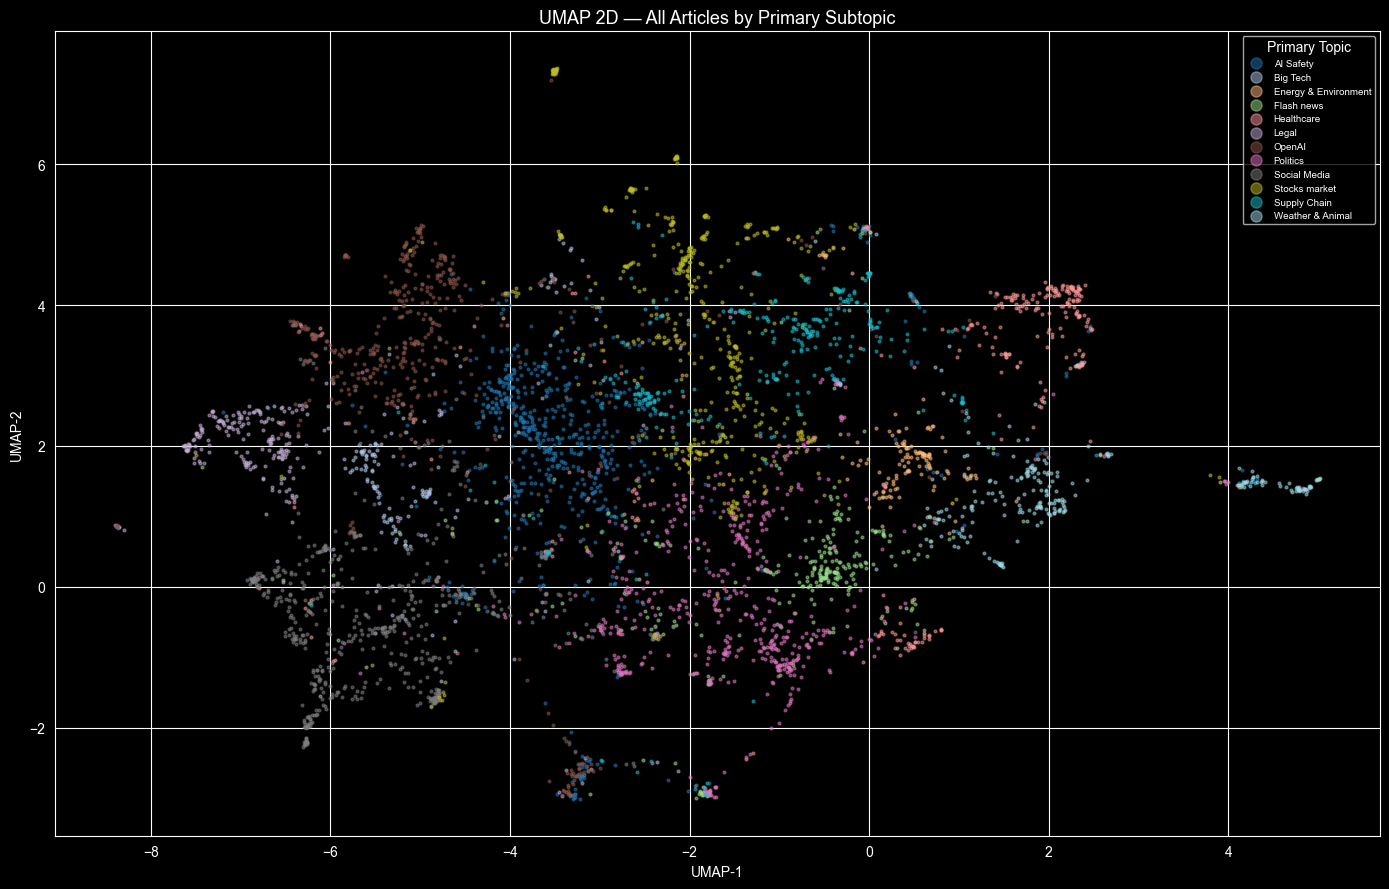

Saved: data/topic_clusters_umap.png


In [37]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from umap import UMAP as UMAP2D

reducer_2d = UMAP2D(n_components=2, metric='cosine', random_state=42, verbose=False)
emb_2d = reducer_2d.fit_transform(embeddings)

# Use primary label (first in subtopics list) for colouring
df['primary_label'] = df['subtopics'].apply(lambda x: x[0] if x else 'Unknown')
unique_labels = sorted(df['primary_label'].unique())
palette = cm.get_cmap('tab20', len(unique_labels))
color_map = {lbl: palette(i) for i, lbl in enumerate(unique_labels)}

fig, ax = plt.subplots(figsize=(14, 9))
for lbl in unique_labels:
    mask = df['primary_label'] == lbl
    ax.scatter(
        emb_2d[mask, 0], emb_2d[mask, 1],
        s=4, alpha=0.5, color=color_map[lbl], label=lbl,
    )
ax.legend(loc='upper right', fontsize=7, markerscale=4, title='Primary Topic')
ax.set_title('UMAP 2D — All Articles by Primary Subtopic', fontsize=13)
ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
plt.tight_layout()
plt.savefig('data/topic_clusters_umap.png', dpi=150)
plt.show()
print('Saved: data/topic_clusters_umap.png')

## Step 8 — Save Outputs

In [38]:
# Save classified articles (same schema as before — drop internal cols)
keep_cols = ['id', 'date', 'section', 'headline', 'body', 'wordcount', 'url', 'subtopic']
df_out = df_exp[keep_cols].copy()
df_out.to_csv('data/classified_articles.csv', index=False)
print(f'Saved: data/classified_articles.csv  ({len(df_out):,} rows)')

# Save topic info for reference / report
topic_summary = (
    topic_info[topic_info['Topic'] >= 0]
    .copy()
    .assign(name=lambda d: d['Topic'].apply(lookup_name))
    [['Topic', 'name', 'Count', 'Representation']]
    .rename(columns={'Topic': 'topic_id', 'name': 'subtopic_name', 'Count': 'articles_primary'})
)
topic_summary.to_csv('data/topic_info.csv', index=False)
print('Saved: data/topic_info.csv')

# Final subtopic distribution (unique articles per subtopic)
dist = (
    df_out.drop_duplicates(subset=['id', 'subtopic'])
    .groupby('subtopic')['id'].count()
    .sort_values(ascending=False)
    .rename('article_count')
)
print('\nFinal subtopic distribution:')
print(dist.to_string())

Saved: data/classified_articles.csv  (12,447 rows)
Saved: data/topic_info.csv

Final subtopic distribution:
subtopic
AI Safety               2029
OpenAI                  1597
Politics                1252
Social Media            1156
Legal                   1072
Stocks market           1069
Supply Chain            1058
Big Tech                 911
Flash news               899
Healthcare               545
Energy & Environment     476
Weather & Animal         383
